<a href="https://colab.research.google.com/github/Hejazee07/diabetes-risk-prediction/blob/main/diabetes_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/diabetes_risk_dataset.csv")
df.head()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
age,0
gender,0
bmi,0
blood_pressure,0
fasting_glucose_level,0
insulin_level,0
HbA1c_level,0
cholesterol_level,0
triglycerides_level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:


df = df.drop("Patient_ID", axis=1)

In [ ]:
df

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,58,Male,21.8,158,89,6.3,5.3,198,132,High,1995,44.1,7.6,7,No,82.7,0.0,Low Risk
5996,73,Male,47.3,193,109,33.7,6.1,250,209,Low,3401,61.4,5.3,10,Yes,150.0,100.0,High Risk
5997,35,Male,31.0,139,90,15.1,5.3,190,164,Moderate,3022,86.7,6.8,3,Yes,102.7,22.3,Low Risk
5998,58,Male,26.2,136,88,6.3,5.5,223,126,High,2311,28.2,8.4,5,No,90.6,3.9,Low Risk


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['physical_activity_level'] = le.fit_transform(df['physical_activity_level'])
df['family_history_diabetes'] = le.fit_transform(df['family_history_diabetes'])
df['diabetes_risk_category'] = le.fit_transform(df['diabetes_risk_category'])

df.head()

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,77,0,33.8,154,93,12.1,5.2,242,194,1,2169,78.4,8.1,4,0,101.1,52.3,2
1,54,1,19.2,123,94,4.6,5.4,212,76,0,1881,16.5,6.6,3,0,60.0,3.7,1
2,25,1,33.7,141,150,10.8,6.9,247,221,1,2811,147.9,6.7,10,1,114.7,87.3,0
3,23,0,32.8,140,145,11.6,6.8,195,193,1,2826,98.3,4.4,9,1,96.6,76.1,0
4,70,1,33.7,165,90,18.3,5.6,217,170,2,2610,65.8,9.1,5,1,107.4,47.7,2


In [ ]:
X = df.drop(["diabetes_risk_category", "diabetes_risk_score"], axis=1)
y = df["diabetes_risk_category"]
df.head()

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,77,0,33.8,154,93,12.1,5.2,242,194,1,2169,78.4,8.1,4,0,101.1,52.3,2
1,54,1,19.2,123,94,4.6,5.4,212,76,0,1881,16.5,6.6,3,0,60.0,3.7,1
2,25,1,33.7,141,150,10.8,6.9,247,221,1,2811,147.9,6.7,10,1,114.7,87.3,0
3,23,0,32.8,140,145,11.6,6.8,195,193,1,2826,98.3,4.4,9,1,96.6,76.1,0
4,70,1,33.7,165,90,18.3,5.6,217,170,2,2610,65.8,9.1,5,1,107.4,47.7,2


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4800, 16)
Testing Data Shape: (1200, 16)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
X_train[:5]

array([[ 1.33431397,  1.02020406, -0.77418129,  0.09869321, -0.95999309,
        -1.09287221, -0.81522529,  0.83296547, -1.02499424, -1.52287098,
        -0.87641844, -0.89283696, -0.0772249 , -0.8882765 , -0.47972741,
        -0.72119744],
       [-0.1601924 ,  1.02020406,  1.372262  ,  0.82707362, -0.70507127,
        -0.87563018, -0.29584946, -0.04858548,  1.62620744, -0.06354163,
         2.03279552,  1.56126772,  0.51872286,  1.24893011, -0.47972741,
         1.34106138],
       [ 1.12081306, -0.98019606, -1.35103792, -1.30203835, -0.32268854,
        -1.26666582,  0.01577604, -0.32907896, -1.50879017, -1.52287098,
        -1.36128743, -1.56512517, -0.00273143, -0.8882765 , -0.47972741,
        -1.57413167],
       [ 1.12081306, -0.98019606,  1.54666051,  1.72354182,  0.79259442,
         0.7971334 ,  0.95065253,  0.71275398,  0.9295413 , -0.06354163,
         1.23146623,  0.6236026 , -2.23753551, -0.03339385, -0.47972741,
         0.97666225],
       [-1.38782264,  1.02020406, -1

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9141666666666667


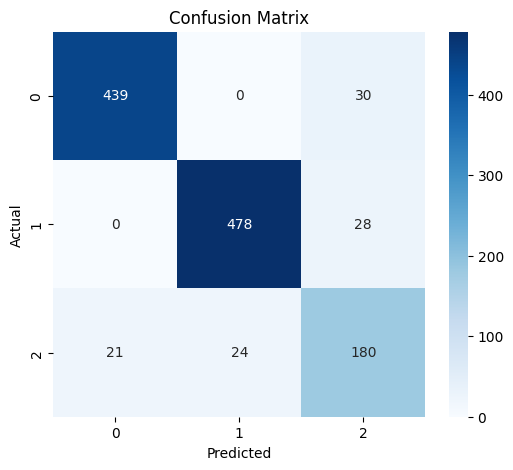

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
train_pred = rf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.989375


In [ ]:

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", accuracy)

Training Accuracy: 0.989375
Testing Accuracy: 0.9141666666666667


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       469
           1       0.95      0.94      0.95       506
           2       0.76      0.80      0.78       225

    accuracy                           0.91      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.92      0.91      0.92      1200



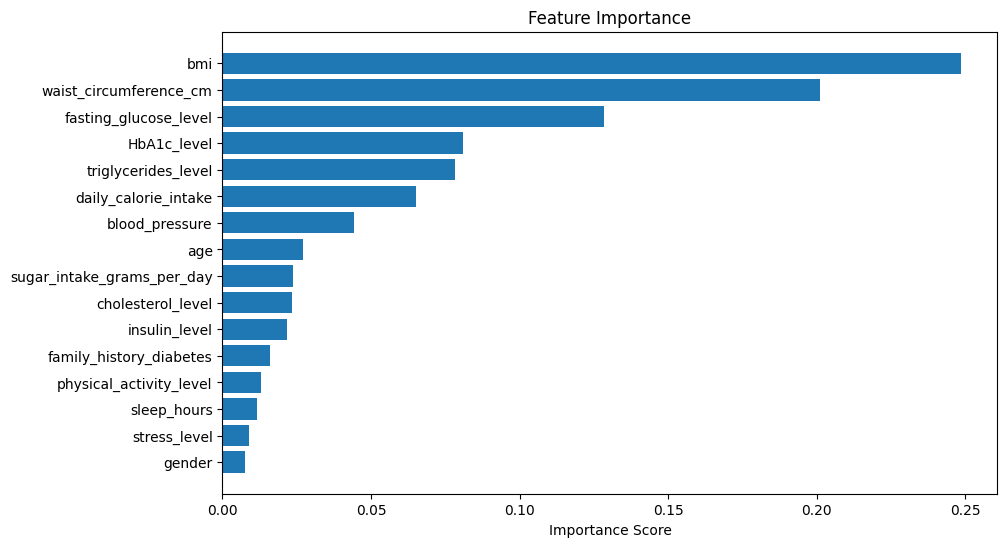

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_

feature_names = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.show()

In [ ]:
df

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,77,0,33.8,154,93,12.1,5.2,242,194,1,2169,78.4,8.1,4,0,101.1,52.3,2
1,54,1,19.2,123,94,4.6,5.4,212,76,0,1881,16.5,6.6,3,0,60.0,3.7,1
2,25,1,33.7,141,150,10.8,6.9,247,221,1,2811,147.9,6.7,10,1,114.7,87.3,0
3,23,0,32.8,140,145,11.6,6.8,195,193,1,2826,98.3,4.4,9,1,96.6,76.1,0
4,70,1,33.7,165,90,18.3,5.6,217,170,2,2610,65.8,9.1,5,1,107.4,47.7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,58,1,21.8,158,89,6.3,5.3,198,132,0,1995,44.1,7.6,7,0,82.7,0.0,1
5996,73,1,47.3,193,109,33.7,6.1,250,209,1,3401,61.4,5.3,10,1,150.0,100.0,0
5997,35,1,31.0,139,90,15.1,5.3,190,164,2,3022,86.7,6.8,3,1,102.7,22.3,1
5998,58,1,26.2,136,88,6.3,5.5,223,126,0,2311,28.2,8.4,5,0,90.6,3.9,1


In [ ]:
import numpy as np

def get_input():
    print("\n--- Enter Patient Details ---")

    try:

        age = float(input("Age (years, e.g., 1-100): "))
        bmi = float(input("BMI (e.g., 15.0-50.0): "))
        waist = float(input("Waist Circumference (cm, e.g., 60-150): "))
        fasting_glucose = float(input("Fasting Glucose (mg/dL, e.g., 70-200): "))
        hba1c = float(input("HbA1c Level (%, e.g., 4.0-15.0): "))
        triglycerides = float(input("Triglycerides (mg/dL, e.g., 50-300): "))
        daily_calorie = float(input("Daily Calorie Intake (kcal, e.g., 1200-3500): "))
        blood_pressure = float(input("Systolic Blood Pressure (mmHg, e.g., 90-180): "))
        sugar_intake = float(input("Sugar Intake per day (grams, e.g., 0-100): "))
        cholesterol = float(input("Total Cholesterol (mg/dL, e.g., 100-300): "))
        insulin = float(input("Insulin Level (mIU/L, e.g., 2.0-25.0): "))
        family_history = int(input("Family History (0=No, 1=Yes): "))
        physical_activity = float(input("Physical Activity Level (Scale 1-5): "))
        sleep = float(input("Sleep Hours (e.g., 4-12): "))
        stress = float(input("Stress Level (Scale 1-5): "))
        gender = int(input("Gender (0=Female, 1=Male): "))

        input_data = np.array([[age, bmi, waist, fasting_glucose, hba1c,
                                triglycerides, daily_calorie, blood_pressure,
                                sugar_intake, cholesterol, insulin,
                                family_history, physical_activity,
                                sleep, stress, gender]])


        input_scaled = scaler.transform(input_data)
        prediction = rf.predict(input_scaled)

        risk_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
        print(f"\nResult: The predicted Diabetes Risk is {risk_map[prediction[0]]}")

    except ValueError:
        print("\n[ERROR] Invalid input: Please enter numerical values only.")
    except NameError as e:
        print(f"\n[ERROR] Model or Scaler not found: {e}")
    except Exception as e:
        print(f"\n[ERROR] An unexpected error occurred: {e}")

get_input()



--- Enter Patient Details ---
